In [ ]:
import os
import xarray as xr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data = {
    f.replace(".nc", ""): xr.open_dataset(f"/content/drive/MyDrive/new_data/{f}")
    for f in os.listdir("/content/drive/MyDrive/new_data/") if f.endswith(".nc")
}

btcdata = xr.open_dataset("/content/drive/MyDrive/new_btc_data.nc")

back = {
    f.replace(".nc", ""): xr.open_dataset(f"/content/drive/MyDrive/back/{f}")
    for f in os.listdir("/content/drive/MyDrive/back/") if f.endswith(".nc")
}
btcback = xr.open_dataset("/content/drive/MyDrive/btc_back.nc")




In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

class DatasetPrepare(Dataset):
    def __init__(self, features, labels, seq_len=48):
      self.data = torch.tensor(features, dtype=torch.float32)
      self.label = torch.tensor(labels, dtype=torch.float32)
      self.seq_len = seq_len
    def __len__(self):
        return len(self.X) - self.seq_len
    @staticmethod
    def build_dataset(back_data, btc_back):
        all_markets = []
        for event, ds in back_data.items():
            tl_arr = ds.time_left.values
            btc_prices = btc_back["btc_price"].sel(event=event).values

            vol_5 = btc_back["vol_5"].sel(event=event).values
            vol_15 = btc_back["vol_15"].sel(event=event).values
            vol_60 = btc_back["vol_60"].sel(event=event).values
            low = btc_back["low"].sel(event=event).values
            high = btc_back["high"].sel(event=event).values
            vol = btc_back["vol"].sel(event=event).values

            for market in ds.market.values:
                rows = []
                price = ds["price"].sel(market=market).values
                cut   = ds["cutoff"].sel(market=market).values

                for i, tl in enumerate(tl_arr):
                    if np.isnan(price[i]):
                        continue
                    rows.append({
                        "time_left": float(tl),
                        "cutoff":    cut[i],
                        "btc_price": btc_prices[i],
                        "price":     price[i],
                        "vol5": vol_5[i],
                        "vol15": vol_15[i],
                        "vol60": vol_60[i],
                        "pct_dist": (btc_prices[i] - cut[i]) / cut[i],
                        "log_price": np.log(btc_prices[i]/cut[i]),
                        "low": low[i],
                        "high": high[i],
                        "candle_spread": high[i] - low[i],
                        "vol": vol[i]
                    })

                df = pd.DataFrame(rows).dropna()
                X = df[["time_left", "cutoff", "btc_price", "vol5", "vol15", "vol60", "pct_dist", "log_price", "low", "high", "candle_spread", "vol"]].values
                y = df["price"].values
                all_markets.append([X, y])
        return all_markets

    def to_windows(X, seq_len=48):
      windows = []
      for i in range(len(X) - seq_len):
          windows.append(X[i : i + seq_len])
      return torch.tensor(np.stack(windows), dtype=torch.float32)


    def __getitem__(self, idx):
        x = self.X[idx : idx + self.seq_len]        # (seq_len, n_features)
        y = self.y[idx + self.seq_len]               # scalar label
        return X, y



In [ ]:
all_markets = DatasetPrepare.build_dataset(data, btcdata)
n_markets = len(all_markets)
train_cut = int(n_markets * 0.85)

train_markets = all_markets[:train_cut]
val_markets   = all_markets[train_cut:]

# Fit scaler on train only
scaler = StandardScaler()
scaler.fit(np.vstack([X for X, y in train_markets]))

SEQ_LEN = 15
HORIZON = 10

def build_windows(markets, scaler, seq_len=SEQ_LEN, horizon=HORIZON):
    X_windows, y_windows = [], []
    for X, y in markets:
        X = scaler.transform(X)
        for i in range(len(X) - seq_len - horizon):
            X_windows.append(X[i : i + seq_len])
            y_windows.append(y[i + seq_len + horizon - 1])
    return np.stack(X_windows), np.array(y_windows)


def make_loader(X, y, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32).to(device),
        torch.tensor(y, dtype=torch.float32).to(device)
    )
    return DataLoader(ds, batch_size=32, shuffle=shuffle)

X_train, y_train = build_windows(train_markets, scaler)
X_val,   y_val   = build_windows(val_markets,   scaler)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)

import math




def balance_by_price_bin(X, y, n_bins=10, seed=42):
    rng = np.random.default_rng(seed)
    bins = np.floor(y * n_bins).astype(int).clip(0, n_bins - 1)

    counts = np.bincount(bins, minlength=n_bins)
    print("Samples per bin before balancing:", counts)

    max_count = counts.max()
    indices = []
    for b in range(n_bins):
        idx = np.where(bins == b)[0]
        if len(idx) == 0:
            continue
        chosen = rng.choice(idx, size=max_count, replace=True)  # replace=True for upsampling
        indices.append(chosen)

    indices = np.concatenate(indices)
    rng.shuffle(indices)
    print(f"Balanced: {max_count} samples × {(counts > 0).sum()} bins = {len(indices)} total")
    return X[indices], y[indices]




# Balance training set only — leave val/test untouched so eval is realistic
X_train, y_train = balance_by_price_bin(X_train, y_train)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)

test_markets = DatasetPrepare.build_dataset(back, btcback)
X_test, y_test = build_windows(test_markets, scaler)
test_loader = make_loader(X_test, y_test, shuffle=False)

Samples per bin before balancing: [563 167 136 105 101 125 121 155 149 605]
Balanced: 605 samples × 10 bins = 6050 total


In [ ]:
class LSTMModel(torch.nn.Module):
  def __init__(self, n_features=12, hidden_size=256, num_layers=4, dropout=0.25):
    super().__init__()
    self.lstm = torch.nn.LSTM(
        input_size=n_features,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout = dropout,
        batch_first=True
    )
    self.fc = torch.nn.Sequential(
            torch.nn.Linear(hidden_size, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
        )
  def forward(self, x):
    out, _ = self.lstm(x)
    out = out[:, -1, :]

    return self.fc(out).squeeze(-1)



Epoch 1  train: 0.2680  val: 0.3621
Epoch 2  train: 0.1902  val: 0.1848
Epoch 3  train: 0.0751  val: 0.0607
Epoch 4  train: 0.0429  val: 0.0252
Epoch 5  train: 0.0369  val: 0.0206
Epoch 6  train: 0.0359  val: 0.0220
Epoch 7  train: 0.0346  val: 0.0213
Epoch 8  train: 0.0336  val: 0.0205
Epoch 9  train: 0.0339  val: 0.0209
Epoch 10  train: 0.0321  val: 0.0202
Epoch 11  train: 0.0323  val: 0.0205
Epoch 12  train: 0.0318  val: 0.0208
Epoch 13  train: 0.0317  val: 0.0210
Epoch 14  train: 0.0310  val: 0.0211
Epoch 15  train: 0.0307  val: 0.0220
Early stopping at epoch 15


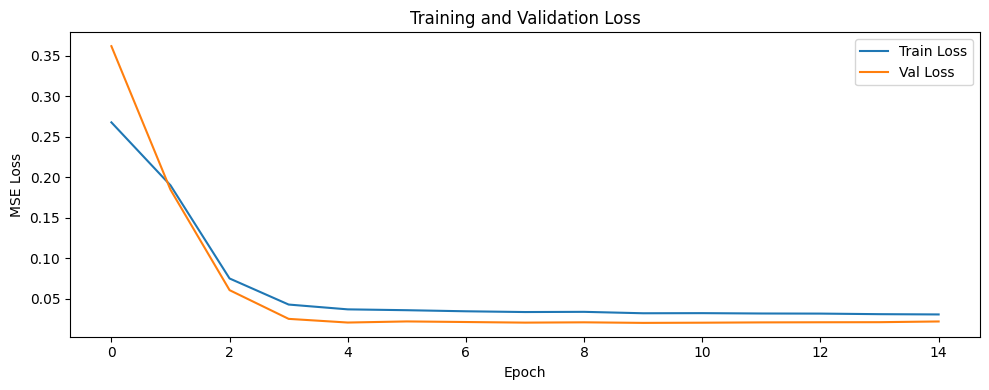

In [ ]:
model = LSTMModel(n_features=12).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
loss_fn = torch.nn.MSELoss()

patience = 5
patience_counter = 0
best_val_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(30):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            val_loss += loss_fn(model(X_batch), y_batch).item()

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    print(f"Epoch {epoch+1}  train: {avg_train:.4f}  val: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break


plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


# Val
all_preds_val, all_true_val = [], []
with torch.no_grad():
    for x_val, y_val in val_loader:
        all_preds_val.append(model(x_val).cpu().numpy())
        all_true_val.append(y_val.cpu().numpy())

preds = np.concatenate(all_preds_val)
true  = np.concatenate(all_true_val)




Train MAE:  0.1367
Train RMSE: 0.1709

Error percentiles on Train:
  p25: 0.0653
  p50: 0.1181
  p75: 0.1823
  p90: 0.2574
  p95: 0.3247


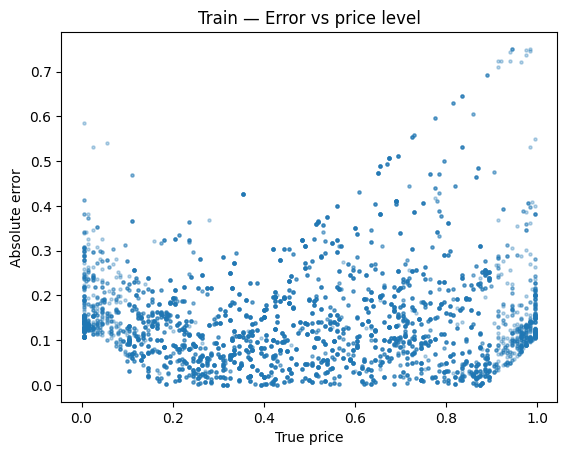


Val MAE:  0.1373
Val RMSE: 0.1702

Error percentiles on val:
  p25: 0.0791
  p50: 0.1164
  p75: 0.1620
  p90: 0.2436
  p95: 0.3537


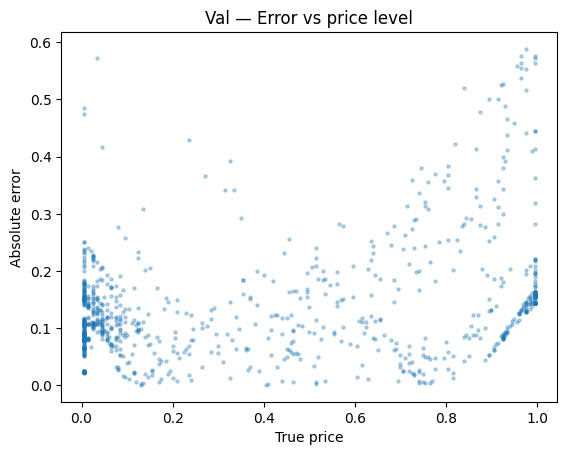


Test MAE:  0.1425
Test RMSE: 0.1721

Error percentiles on TEST:
  p25: 0.0960
  p50: 0.1228
  p75: 0.1621
  p90: 0.2420
  p95: 0.3518


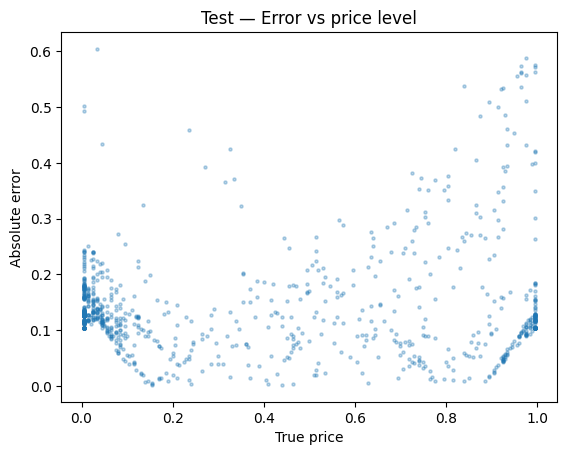

Naive baseline MAE (test):  0.0744
Naive baseline RMSE (test): 0.1303
Model RMSE (test):          0.1721


In [ ]:
all_preds_train, all_true_train = [], []
with torch.no_grad():
    for x_train, y_train in train_loader:
        all_preds_train.append(model(x_train).cpu().numpy())
        all_true_train.append(y_train.cpu().numpy())

train_preds = np.concatenate(all_preds_train)
train_true  = np.concatenate(all_true_train)

train_mae  = np.mean(np.abs(train_preds - train_true))
train_rmse = np.sqrt(np.mean((train_preds - train_true)**2))
print(f"\nTrain MAE:  {train_mae:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")

print(f"\nError percentiles on Train:")
abs_errors_train = np.abs(train_preds - train_true)
for p in [25, 50, 75, 90, 95]:
    print(f"  p{p}: {np.percentile(abs_errors_train, p):.4f}")

plt.scatter(train_true, abs_errors_train, alpha=0.3, s=5)
plt.xlabel("True price")
plt.ylabel("Absolute error")
plt.title("Train — Error vs price level")
plt.show()

preds = np.concatenate(all_preds)
true  = np.concatenate(all_true)

mae  = np.mean(np.abs(preds - true))
rmse = np.sqrt(np.mean((preds - true)**2))
print(f"\nVal MAE:  {mae:.4f}")
print(f"Val RMSE: {rmse:.4f}")

print(f"\nError percentiles on val:")
abs_errors = np.abs(preds - true)
for p in [25, 50, 75, 90, 95]:
    print(f"  p{p}: {np.percentile(abs_errors, p):.4f}")

plt.scatter(true, np.abs(preds - true), alpha=0.3, s=5)
plt.xlabel("True price")
plt.ylabel("Absolute error")
plt.title("Val — Error vs price level")
plt.show()

# Test
all_preds, all_true = [], []
with torch.no_grad():
    for x_test, y_test in test_loader:
        all_preds.append(model(x_test).cpu().numpy())
        all_true.append(y_test.cpu().numpy())        # ← fixed

test_preds = np.concatenate(all_preds)
test_true  = np.concatenate(all_true)
test_mae  = np.mean(np.abs(test_preds - test_true))
test_rmse = np.sqrt(np.mean((test_preds - test_true)**2))
print(f"\nTest MAE:  {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")



print(f"\nError percentiles on TEST:")
abs_errors = np.abs(test_preds - test_true)
for p in [25, 50, 75, 90, 95]:
    print(f"  p{p}: {np.percentile(abs_errors, p):.4f}")

plt.scatter(test_true, np.abs(test_preds - test_true), alpha=0.3, s=5)
plt.xlabel("True price")
plt.ylabel("Absolute error")
plt.title("Test — Error vs price level")
plt.show()

naive_preds_test = np.array([
    y[i + SEQ_LEN - 1]
    for X, y in test_markets
    for i in range(len(X) - SEQ_LEN - HORIZON)
])

true_for_naive = np.array([
    y[i + SEQ_LEN + HORIZON - 1]
    for X, y in test_markets
    for i in range(len(X) - SEQ_LEN - HORIZON)
])

naive_rmse_test = np.sqrt(np.mean((naive_preds_test - true_for_naive) ** 2))
naive_mae_test  = np.mean(np.abs(naive_preds_test - true_for_naive))
print(f"Naive baseline MAE (test):  {naive_mae_test:.4f}")
print(f"Naive baseline RMSE (test): {naive_rmse_test:.4f}")
print(f"Model RMSE (test):          {test_rmse:.4f}")

In [ ]:
def backtester_lstm(model, markets, scaler, deviation, seq_len=SEQ_LEN, horizon=HORIZON, device=device):
    model.eval()
    final_values = []
    final_trades = []
    final_port_hist = []

    with torch.no_grad():
        for X_raw, y in markets:
            X = scaler.transform(X_raw)

            cash = 1000
            position = 0
            total_trades = 0
            portfolio_hist = []

            # need at least seq_len steps before we can predict
            for timestep in range(seq_len, len(X) - horizon):
                window = X[timestep - seq_len : timestep]  # (seq_len, 12)
                x_tensor = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)  # (1, seq_len, 12)
                predprice = model(x_tensor).item()
                current_price = y[timestep]

                diff = (predprice - current_price) * 100
                multiple = round(2 * abs(diff))
                multiple = max(1, min(multiple, 50))  # cap so one bad prediction doesn't blow up

                if diff > (deviation - 0.005) * 100:
                    # model thinks price will go up → buy
                    if position < 0:
                        cash += current_price * abs(position)
                        total_trades += abs(position)
                        position = 0
                    if position < 1000:
                        position += multiple
                        cash -= current_price * multiple
                        total_trades += multiple

                elif -diff > (deviation - 0.005) * 100:
                    # model thinks price will go down → sell
                    if position > 0:
                        cash -= current_price * position
                        total_trades += position
                        position = 0
                    if position > -1000:
                        position -= multiple
                        cash += current_price * multiple
                        total_trades += multiple

                else:
                    # no signal → close position
                    if position != 0:
                        cash += position * current_price
                        total_trades += abs(position)
                        position = 0

                portfolio_value = cash + position * current_price
                portfolio_hist.append(portfolio_value)

            # close any open position at end of market
            if position != 0:
                cash += position * y[-1]
                total_trades += abs(position)
                position = 0

            final_values.append(int(cash))
            final_trades.append(total_trades)
            final_port_hist.append(portfolio_hist)

    return final_values, final_trades, final_port_hist


def plot_portfolio(final_values):
    plt.figure(figsize=(12, 5))
    plt.plot(final_values, marker="o", markersize=3, linewidth=1)
    plt.axhline(y=1000, color="gray", linestyle="--", linewidth=1, label="Starting capital ($1000)")
    plt.axhline(y=0, color="red", linestyle="--", linewidth=0.8, label="Zero")
    plt.title("Final Portfolio Value per Market")
    plt.xlabel("Market Index")
    plt.ylabel("Portfolio Value ($)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_cumulative(port_hists, title="Cumulative PnL"):
    max_len = max(len(h) for h in port_hists)
    padded = [h + [h[-1]] * (max_len - len(h)) for h in port_hists]
    cumulative = [sum(step) - 1000 * len(port_hists) for step in zip(*padded)]

    plt.figure(figsize=(12, 5))
    plt.plot(cumulative, linewidth=1)
    plt.axhline(y=0, color="gray", linestyle="--", linewidth=1, label="Break even")
    plt.title(title)
    plt.xlabel("Timestep")
    plt.ylabel("PnL ($)")
    plt.legend()
    plt.tight_layout()
    plt.show()

class NaiveModel:
    """Predicts current price (last value in window) — mirrors the naive RMSE baseline."""
    def __call__(self, x_tensor):
        return x_tensor[0, -1, 0]

    def eval(self):
        return self

    def state_dict(self):
        return {}
naive_model = NaiveModel()

final_values, final_trades, final_port_hist = backtester_lstm(
    naive_model, test_markets, scaler, deviation=0.03
)


Training Data
Avg final value: $1092.83
Win rate: 3/12 markets profitable
Min: $-62  Max: $2659


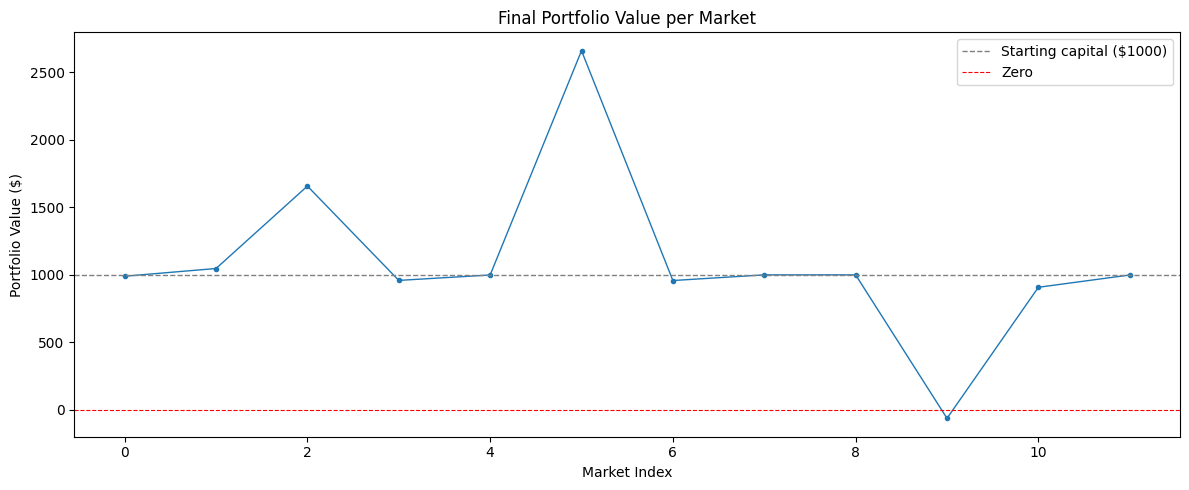

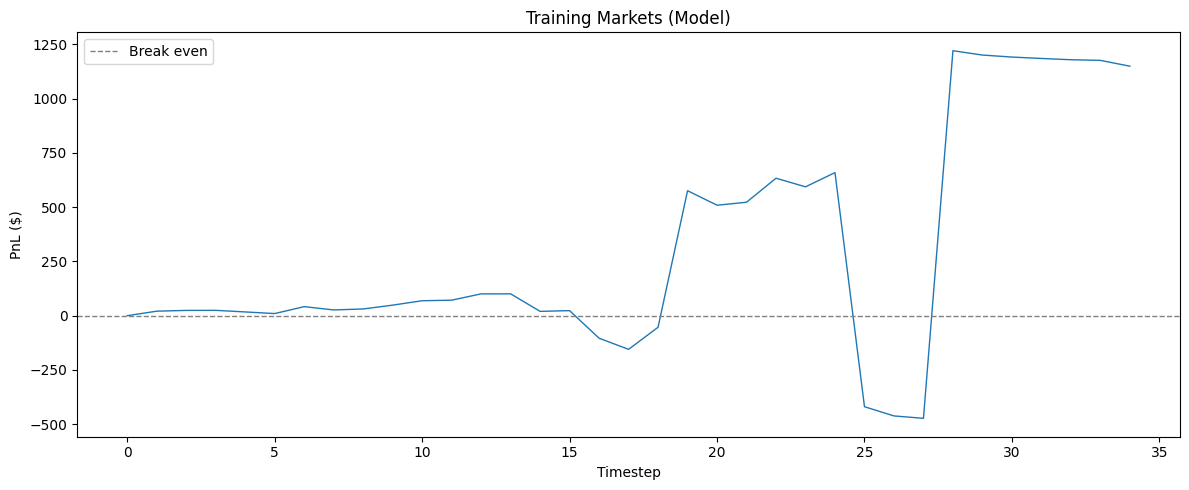

Testing Data
Avg final value: $1016.15
Win rate: 4/27 markets profitable
Min: $456  Max: $1747


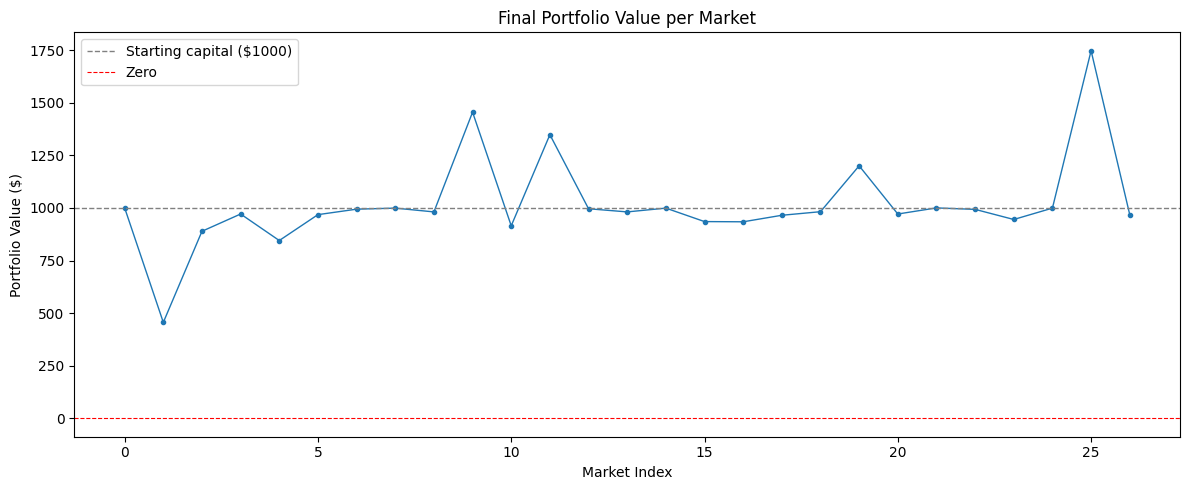

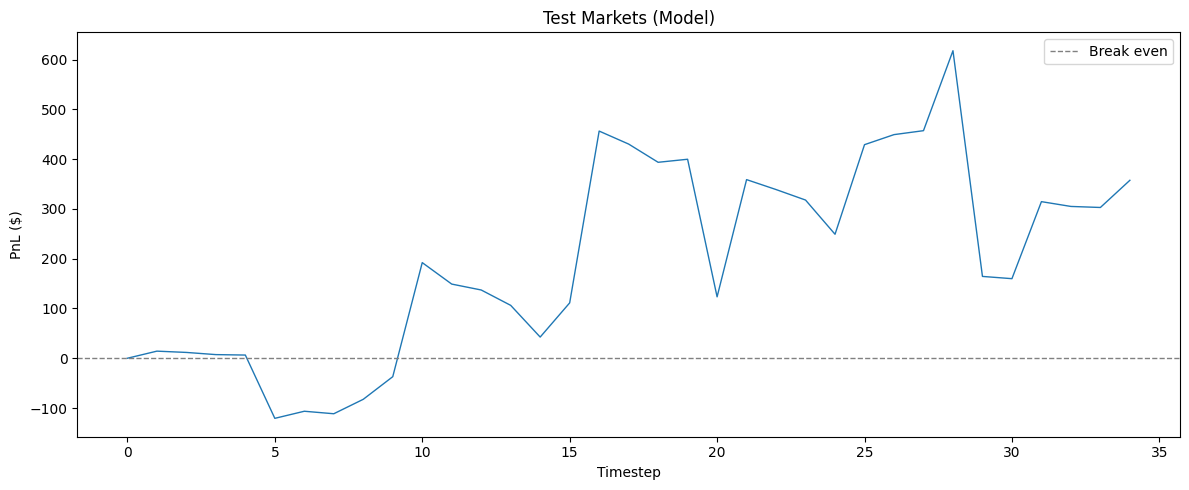

Baseline Data
Avg final value: $930.11
Win rate: 8/27 markets profitable
Min: $47  Max: $1803


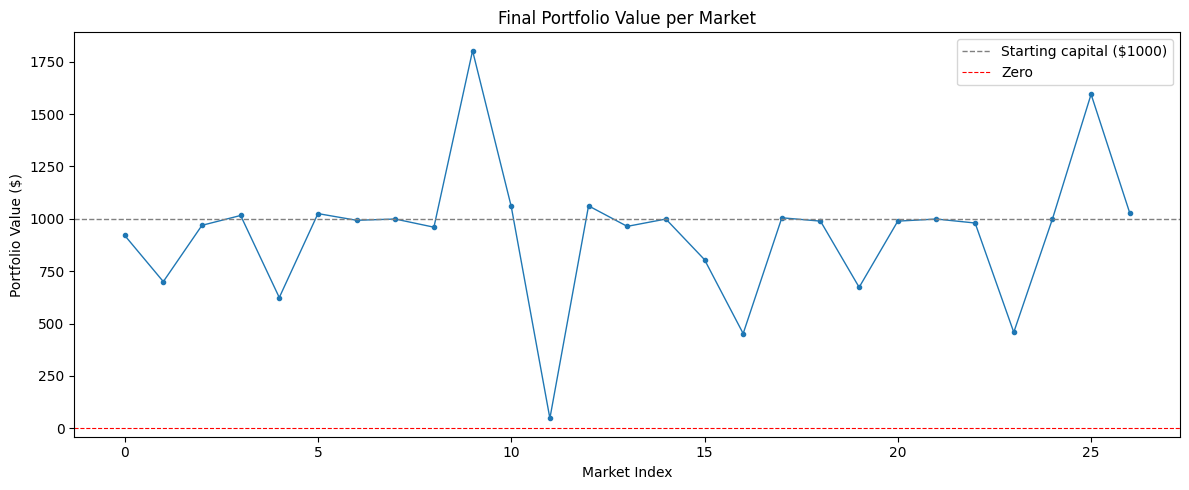

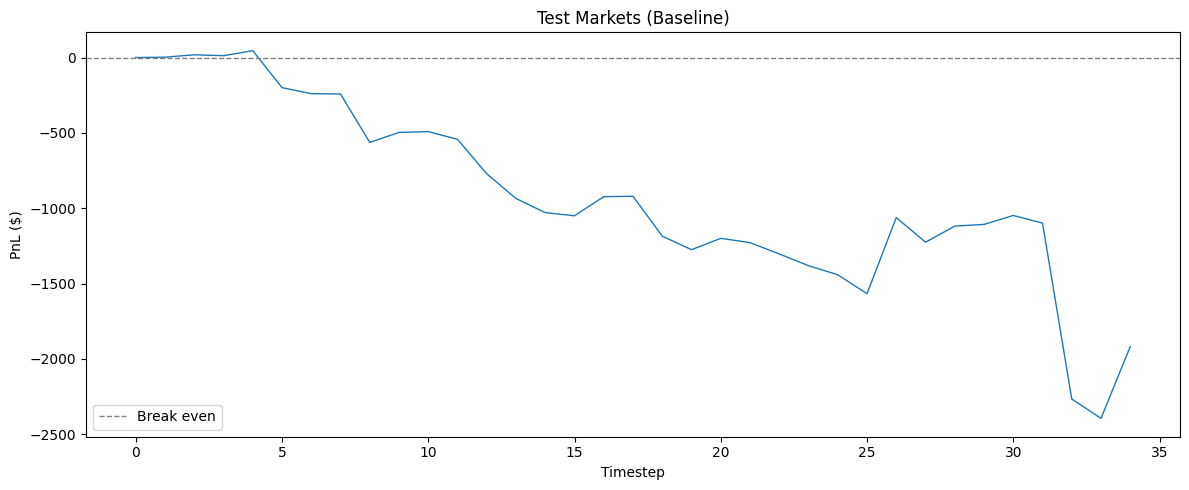

In [ ]:
model.load_state_dict(torch.load("best_model.pt"))
final_values, final_trades, final_port_hist = backtester_lstm(
    model, val_markets, scaler, deviation=0.03
)
print("Training Data")
print(f"Avg final value: ${sum(final_values)/len(final_values):.2f}")
print(f"Win rate: {sum(v > 1000 for v in final_values)}/{len(final_values)} markets profitable")
print(f"Min: ${min(final_values)}  Max: ${max(final_values)}")
plot_portfolio(final_values)
plot_cumulative(final_port_hist, title="Training Markets (Model)")


final_values, final_trades, final_port_hist = backtester_lstm(
    model, test_markets, scaler, deviation=0.03
)
print("Testing Data")
print(f"Avg final value: ${sum(final_values)/len(final_values):.2f}")
print(f"Win rate: {sum(v > 1000 for v in final_values)}/{len(final_values)} markets profitable")
print(f"Min: ${min(final_values)}  Max: ${max(final_values)}")
plot_portfolio(final_values)
plot_cumulative(final_port_hist, title="Test Markets (Model)")

final_values, final_trades, final_port_hist = backtester_lstm(
    naive_model, test_markets, scaler, deviation=0.03
)

print("Baseline Data")
print(f"Avg final value: ${sum(final_values)/len(final_values):.2f}")
print(f"Win rate: {sum(v > 1000 for v in final_values)}/{len(final_values)} markets profitable")
print(f"Min: ${min(final_values)}  Max: ${max(final_values)}")
plot_portfolio(final_values)
plot_cumulative(final_port_hist, title="Test Markets (Baseline)")

